In [1]:
import numpy as np
import pandas as pd
from plotnine import aes
from plotnine import element_text
from plotnine import facet_wrap
from plotnine import geom_bar
from plotnine import ggplot
from plotnine import scale_fill_manual
from plotnine import theme
from plotnine import theme_minimal
from sqlalchemy import create_engine
from sqlalchemy import func
from sqlalchemy.orm import Query

import src
from src.data.models import Channel
from src.data.models import Comment
from src.data.models import Video

In [2]:
engine = create_engine(src.PS_ENGINE)
# session = Session(engine)

In [3]:
comments_query = (
    Query(Comment.id, func.count(Comment.id))
    .filter(Comment.video_id == Video.id)
    .with_entities(func.count(Comment.id))
    .scalar_subquery()
)
query = (
    Query(Channel)
    .join(Video)
    .group_by(Channel)
    .filter(Video.format == "videos")
    .with_entities(
        Channel.channel,
        Channel.channel_follower_count,
        func.count().label("n_videos"),
        func.sum(Video.like_count).label("sum_video_likes"),
        func.avg(Video.like_count).label("mean_video_likes"),
        func.avg(Video.view_count).label("mean_video_views"),
        func.avg(Video.duration).label("mean_video_length"),
        func.avg(comments_query).label("mean_n_comments"),
    )
    .order_by(Channel.channel_follower_count.desc())
)


with engine.connect() as conn:
    df = pd.read_sql(query.statement, conn)

df.channel = df.channel.replace({"BÜNDNIS 90/DIE GRÜNEN": "Grüne"})
df

,channel,channel_follower_count,n_videos,sum_video_likes,mean_video_likes,mean_video_views,mean_video_length,mean_n_comments
0,AfD-Fraktion Bundestag,388000,5259,20300109.0,3860.070165,45723.747481,434.221905,397.188249
1,AfD TV,250000,1593,5409085.0,3395.533584,41554.372254,641.322662,376.419335
2,DIE LINKE,29000,1523,204225.0,134.093894,6568.816152,847.108995,23.613263
3,Grüne,26100,1628,72183.0,44.338452,6637.413391,621.851351,0.526413
4,SPD,24200,1643,95416.0,58.074254,4824.698722,960.291540,13.225198
5,FDP,23300,1962,24466.0,12.469929,4175.585627,644.979613,4.113660
6,CDU,21900,2141,74528.0,34.809902,7264.162541,525.935544,20.007473
7,CSU,5170,740,16931.0,22.879730,7070.121622,449.900000,2.022973


In [4]:
df["log_sum_video_likes"] = np.log(df["sum_video_likes"])

In [5]:
df_long = pd.melt(
    df,
    id_vars="channel",
    var_name="variable",
    value_vars=[
        "channel_follower_count",
        "log_sum_video_likes",
        "n_videos",
        "mean_video_likes",
        "mean_video_views",
        "mean_video_length",
        "mean_n_comments",
    ],
)

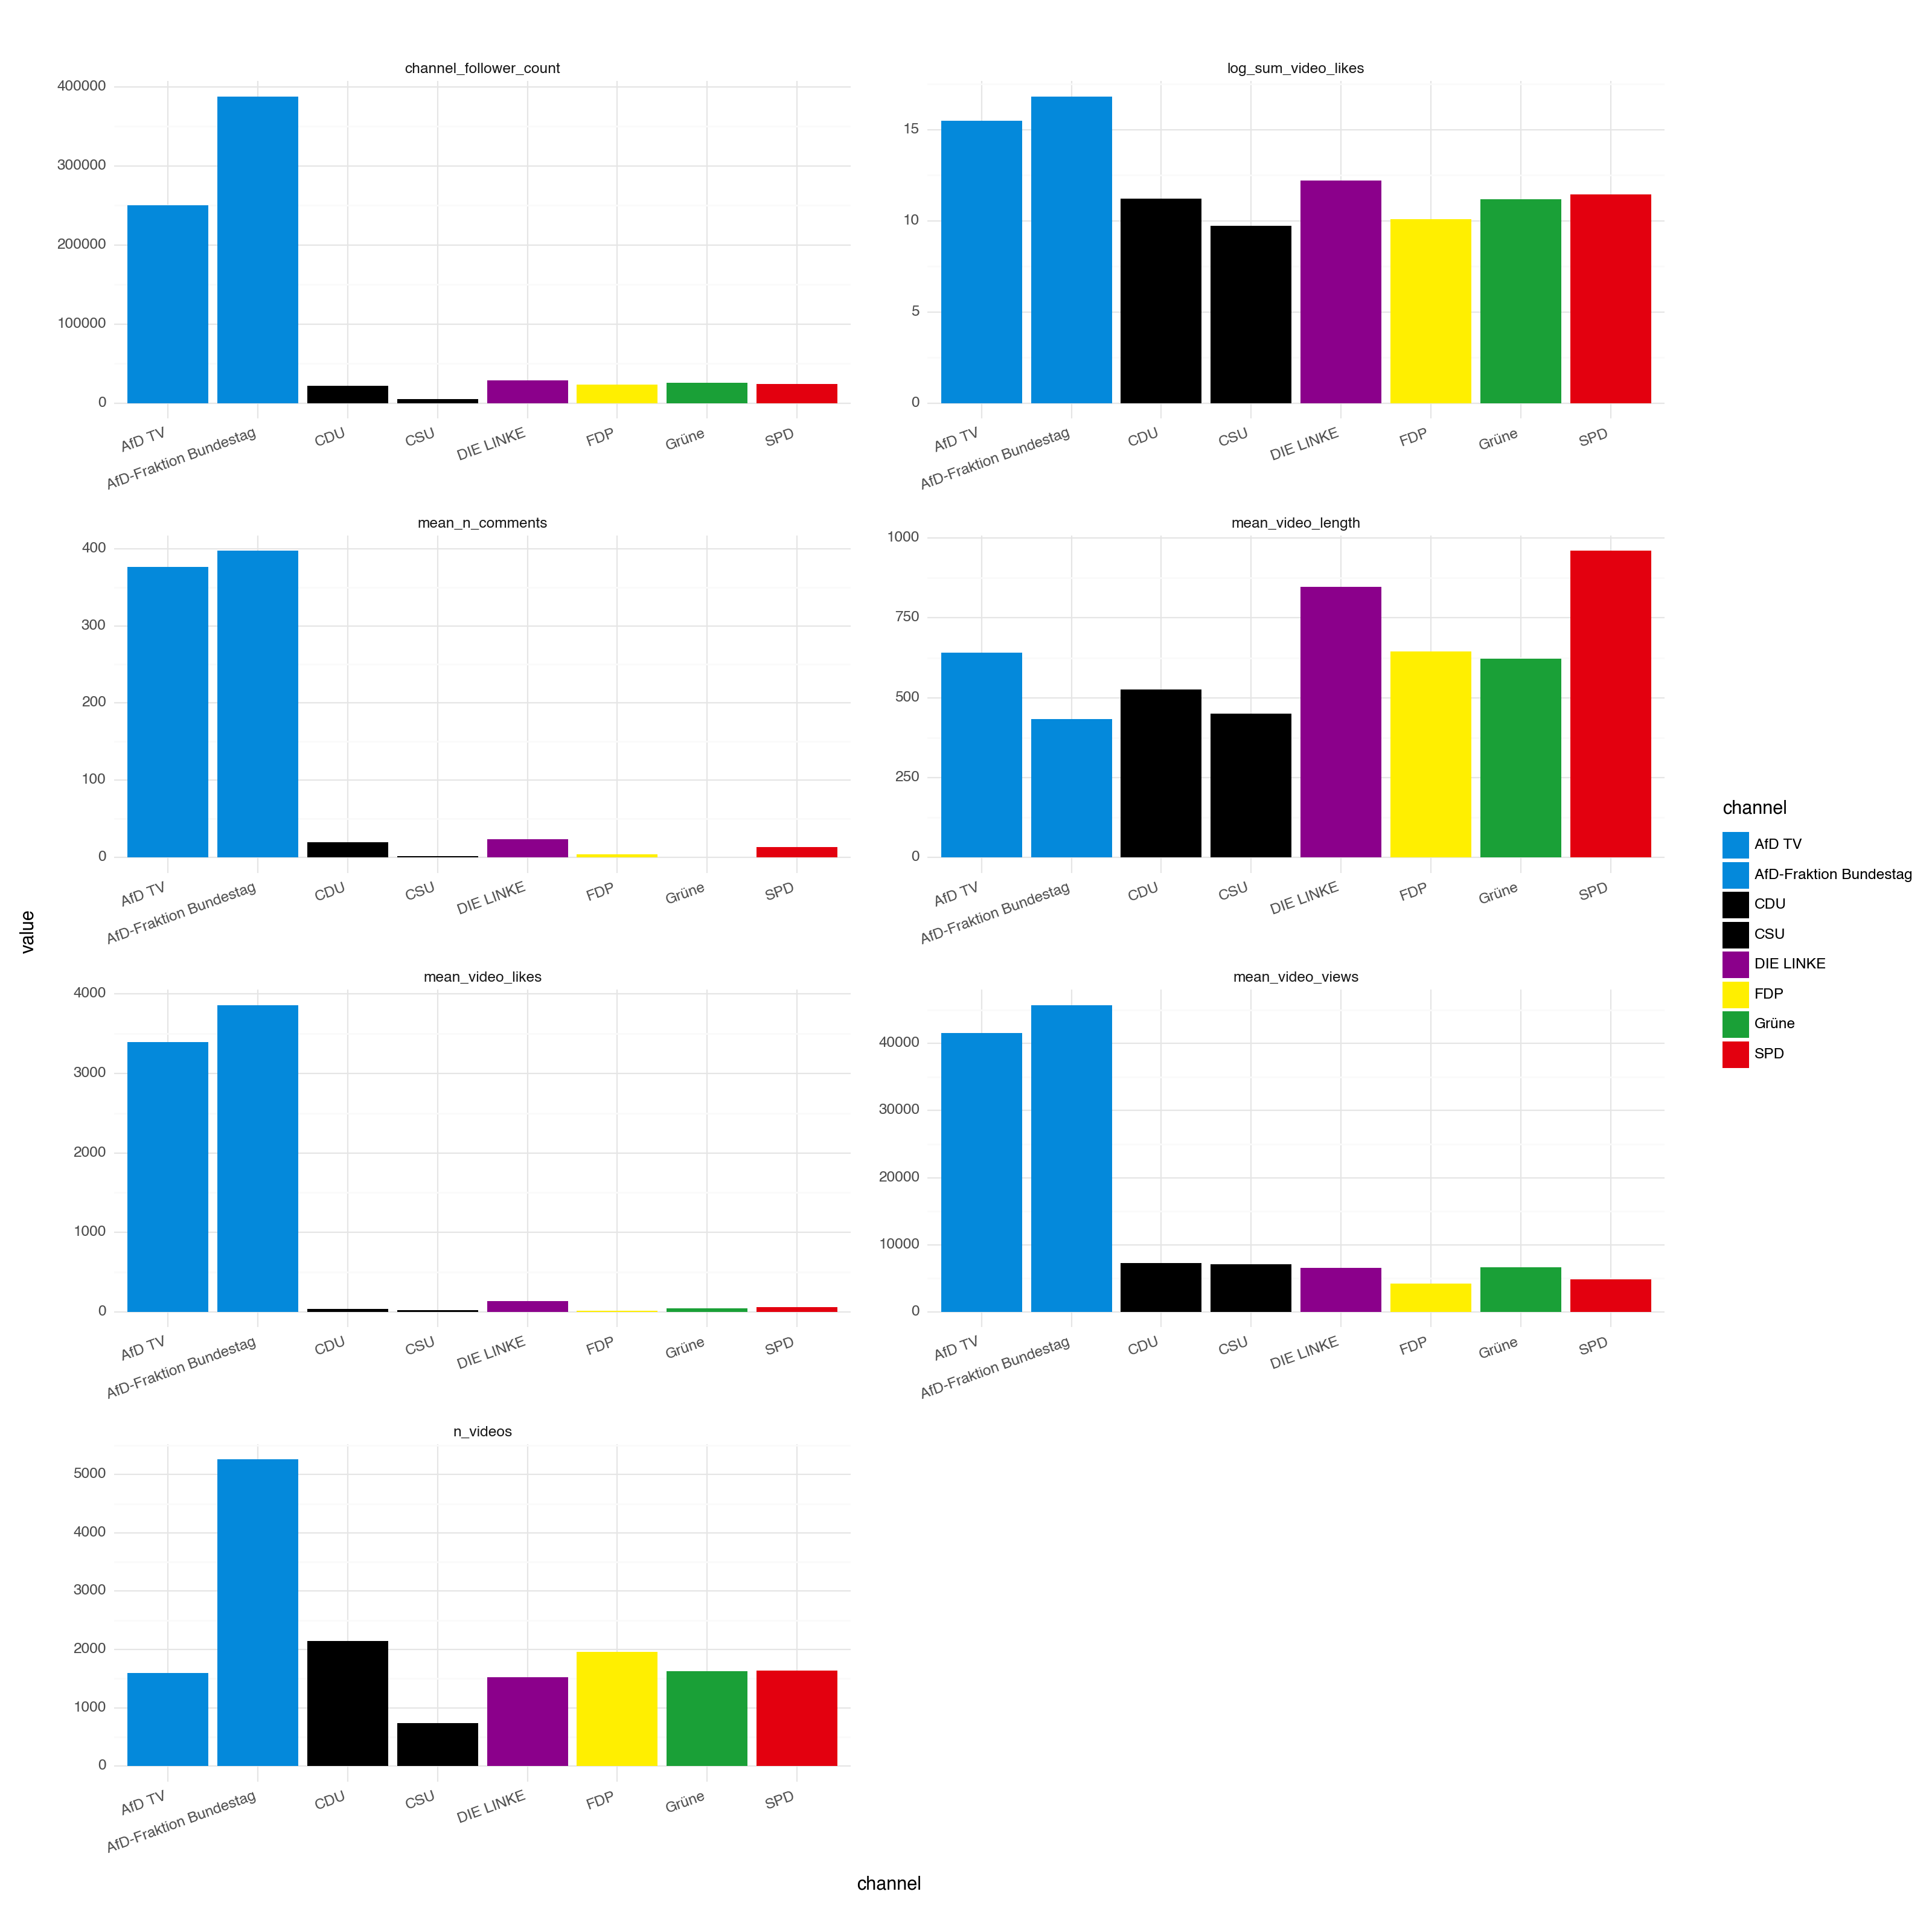

<Figure Size: (1600 x 1600)>

In [6]:

(
    ggplot(df_long, mapping=aes(x="channel", y="value", fill="channel"))
    + geom_bar(stat="identity")
    + facet_wrap("~variable", scales="free", ncol=2)
    + scale_fill_manual(src.colormap)
    + theme_minimal()
    + theme(axis_text_x = element_text(rotation=20, hjust=1), figure_size=(16,16))
)